## Check if integral of |W| divided by frequency band depends on oscillation frequency

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

path.append('../../signals/')
import signals as sg

import matlab.engine

In [2]:
eng = matlab.engine.start_matlab()

# Two synthetic signals:

$$
s_1 = \cos(2\pi f_1 t) + \epsilon_1,
$$

$$
s_2 = \cos(2\pi f_2 t) + \epsilon_2,
$$

where $f_1=0.02\,$Hz, $f_2=0.04\,$Hz, and $\epsilon_{1,2} \sim N(0, 1)$ (white noise).

In [39]:
T = 4000 # s
dt = 0.5 # s
Fs = 1/dt
nt = int(T/dt)

f1, f2 = 0.1, 0.2 # Hz

t = np.arange(nt)*dt

s1 = sg.cosine(T, f1, sampling_frequency=Fs)[1] + np.random.randn(nt)
s2 = sg.cosine(T, f2, sampling_frequency=Fs)[1] + np.random.randn(nt)

In [62]:
integration_band = slice(0.01, 0.4)

### Compute CWT

In [63]:
w1 = wf.matlab_cwt(eng, s1, Fs, voices_per_octave=24)
w2 = wf.matlab_cwt(eng, s2, Fs, voices_per_octave=24)

## Show time-averaged $|W|$ against $f$ 

Text(0.5, 1.0, 'Spectra from cosines with white noise')

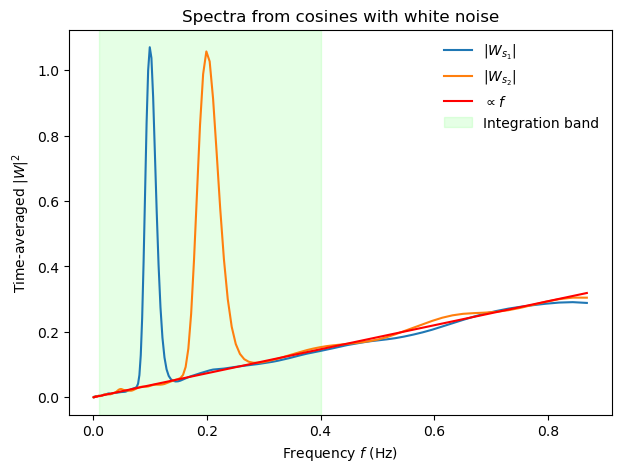

In [64]:
f, ax = plt.subplots(figsize=(7,5))

ax.plot(w1.f, w1.wt_amp.mean('t')**2, label='$|W_{s_1}|$')
ax.plot(w2.f, w2.wt_amp.mean('t')**2, label='$|W_{s_2}|$')

ax.plot(w1.f, w1.f/1.65**2, color='r', label=r"$\propto f$")

ax.set(xlabel='Frequency $f$ (Hz)', ylabel = r'Time-averaged $|W|^2$')

ax.axvspan(integration_band.start, integration_band.stop, color='lime', alpha=0.1, label='Integration band')
ax.legend(frameon=False)
ax.set_title('Spectra from cosines with white noise')

In [65]:
sum1 = w1.wt_amp.mean('t')[::-1].sel(f=integration_band).sum('f')  # trapz integration along $f$ inside the integration band
sum2 = w2.wt_amp.mean('t')[::-1].sel(f=integration_band).sum('f')  

In [66]:
print(f"Sum of |W|^2 for 0.1-Hz cosine = {sum1.item():.3f}")
print(f"Sum of |W|^2 for 0.2-Hz cosine = {sum2.item():.3f}")

Sum of |W|^2 for 0.1-Hz cosine = 30.443
Sum of |W|^2 for 0.2-Hz cosine = 29.402
